#### Завдання 2. Класифікація сцен (Places365 Mini)
- Мета: Розпізнавати тип сцени на зображенні (вулиці, ліс, море).
- Датасет:
    - Places365 Mini (https://www.kaggle.com/datasets/pankajkumar2002/places365/data)
    - Intel Image Classification (https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data)
- Опис:
    - Використати попередньо натреновану CNN (ResNet18) для transfer learning.
    - Замінити fc шар на 10–20 класів (залежно від підмножини).
    - Навчити модель на невеликому наборі даних і перевірити точність.
- Очікуваний результат: Модель класифікує сцени на зображеннях з точністю >70%.

Знайдено 3 класів: ['forest', 'sea', 'street']...
Будемо використовувати: cpu
Модель ResNet18 завантажена, останній шар замінено.
Епоха 1/5
----------
train Втрати: 0.3595 Точність: 0.8766
val Втрати: 0.0979 Точність: 0.9791
Епоха 2/5
----------
train Втрати: 0.1532 Точність: 0.9556
val Втрати: 0.0623 Точність: 0.9872
Епоха 3/5
----------
train Втрати: 0.1332 Точність: 0.9602
val Втрати: 0.0476 Точність: 0.9906
Епоха 4/5
----------
train Втрати: 0.1218 Точність: 0.9614
val Втрати: 0.0424 Точність: 0.9912
Епоха 5/5
----------
train Втрати: 0.1213 Точність: 0.9619
val Втрати: 0.0386 Точність: 0.9912

Оцінка на тестових даних...
Точність на 3458 тестових зображеннях: 99.13 %


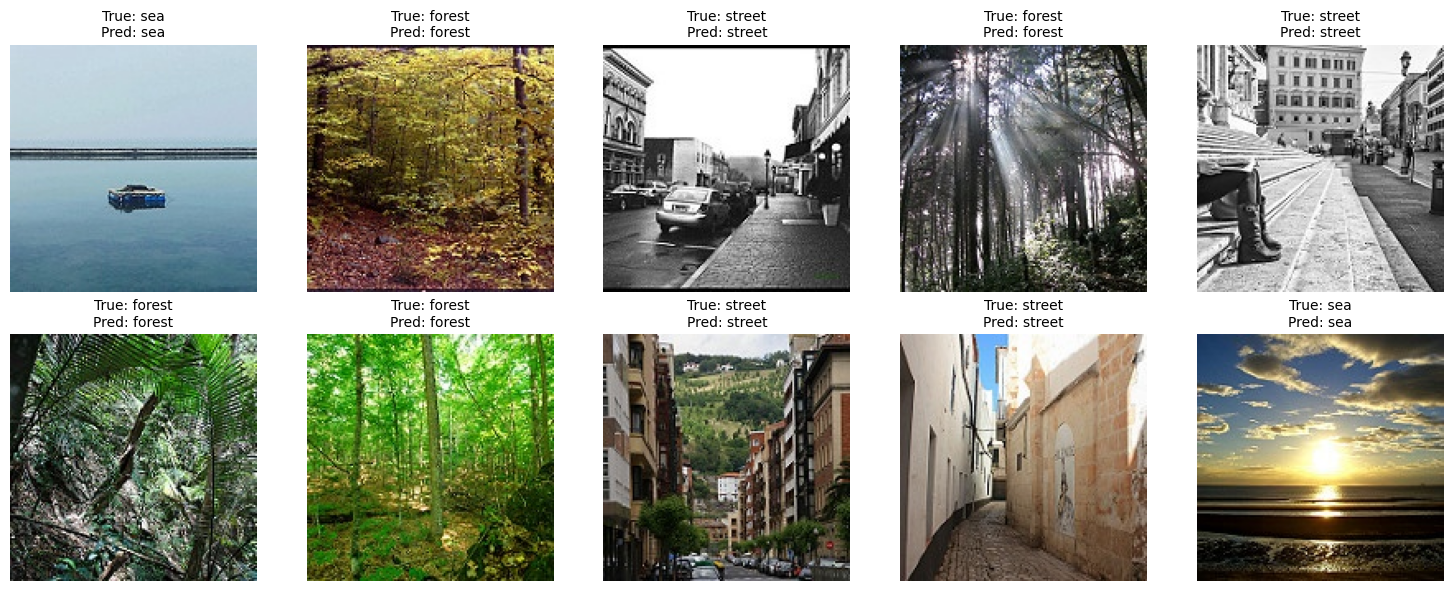

In [32]:
%matplotlib inline 

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Підготуємо дані
data_dir = 'Intel Image Classification' 
train_dir = os.path.join(data_dir, 'train_samples')
valid_dir = os.path.join(data_dir, 'valid_samples')
test_dir = os.path.join(data_dir, 'test_samples')


# Перевіримо, чи існують вказані шляхи
if not all(os.path.exists(p) for p in [train_dir, valid_dir, test_dir]):
    print("ПОМИЛКА: Шляхи до даних не знайдено.")
    print(f"Перевірте, чи правильно вказано базовий шлях '{data_dir}'")
else:
    # Проведемо трансформації для зображень. 
    # 1. Змінемо розмір до 224x224 пікселів.
    # 2. Перетворимо на тензор (формат даних для PyTorch).
    # 3. Нормалізуємо канали зображення (середнє і стандартне відхилення взяті з ImageNet).
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(), # Аугментація: випадково віддзеркалюємо зображення
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }

    # Створимо датасети
    image_datasets = {
        'train': datasets.ImageFolder(train_dir, data_transforms['train']),
        'val': datasets.ImageFolder(valid_dir, data_transforms['val'])
    }
    
    # Створимо завантажувачі даних (DataLoaders)
    dataloaders = {
        'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
        'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=32, shuffle=False)
    }

    # Отримаємо кількість класів (папок) та їх назви
    class_names = image_datasets['train'].classes
    num_classes = len(class_names)
    print(f"Знайдено {num_classes} класів: {class_names[:5]}...")

    # Визначаємо, чи доступний GPU (CUDA) для прискорення розрахунків
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Будемо використовувати: {device}")
    
 
    # Завантажимо попередньо натреновану модель ResNet18
    model = models.resnet18(pretrained=True)

    # "Заморозимо" всі шари моделі, щоб їх ваги не оновлювалися
    for param in model.parameters():
        param.requires_grad = False

    # Отримуємо кількість вхідних ознак останнього шару (model.fc)
    num_ftrs = model.fc.in_features

    # Замінимо останній шар на новий, з потрібною нам кількістю виходів (num_classes)
    model.fc = nn.Linear(num_ftrs, num_classes)

    # Перемістимо модель на GPU, якщо він доступний
    model = model.to(device)
    print("Модель ResNet18 завантажена, останній шар замінено.")
    

    # Встановимо функцію втрат та оптимізатор
    # Оптимізатору передаємо ТІЛЬКИ параметри нового шару (model.fc)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9)

    # Функція для тренування моделі
    def train_model(model, criterion, optimizer, num_epochs=5):
        for epoch in range(num_epochs):
            print(f'Епоха {epoch+1}/{num_epochs}')
            print('-' * 10)

            # Кожна епоха має фазу тренування і валідації
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Встановити модель в режим тренування
                else:
                    model.eval()   # Встановити модель в режим оцінки

                running_loss = 0.0
                running_corrects = 0

                # Ітерація по даних
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # Обнулити градієнти
                    optimizer.zero_grad()

                    # Прямий прохід
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # Зворотний прохід + оптимізація (тільки у фазі тренування)
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # Статистика
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                epoch_loss = running_loss / len(image_datasets[phase])
                epoch_acc = running_corrects.double() / len(image_datasets[phase])

                print(f'{phase} Втрати: {epoch_loss:.4f} Точність: {epoch_acc:.4f}')        
        return model

    # Запустимо тренування!
    model_trained = train_model(model, criterion, optimizer, num_epochs=5)

    
    print("\nОцінка на тестових даних...")       
    #  Створимо тестовий датасет і завантажувач
    test_dataset = datasets.ImageFolder(test_dir, data_transforms['val'])
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # 2. Точність на всьому тесті
    model_trained.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_trained(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f'Точність на {total} тестових зображеннях: {accuracy:.2f} %')
    
    # 3. Візуалізація 10 випадкових тестових фото
    # Збираємо всі файли і їх правильні мітки
    all_test_images = []
    all_labels = []
    for root, dirs, files in os.walk(test_dir):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_test_images.append(os.path.join(root, f))
                # Мітка = назва підпапки
                all_labels.append(os.path.basename(root))
    
    # Випадково обираємо 10 фото
    sample_indices = random.sample(range(len(all_test_images)), min(10, len(all_test_images)))
    
    fig, axes = plt.subplots(2, 5, figsize=(15,6))
    axes = axes.flatten()
    
    for i, idx in enumerate(sample_indices):
        img_path = all_test_images[idx]
        true_label = all_labels[idx]
    
        img = Image.open(img_path).convert('RGB')
        input_tensor = data_transforms['val'](img).unsqueeze(0).to(device)
    
        with torch.no_grad():
            output = model_trained(input_tensor)
            _, pred = torch.max(output, 1)
            predicted_class = class_names[pred.item()]
    
        axes[i].imshow(np.array(img))
        axes[i].set_title(f'True: {true_label}\nPred: {predicted_class}', fontsize=10)
        axes[i].axis('off')
    
    # Прибираємо пусті осі, якщо фото менше ніж 10
    for j in range(len(sample_indices), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()    

#### Завдання 3. Виявлення об’єктів на зображеннях (Pascal VOC або COCO mini)
- Мета: Навчитися визначати bounding box об’єктів.
- Датасет:
    - Pascal VOC або COCO (невелика підмножина)
    - Indoor Objects Detection (https://www.kaggle.com/datasets/thepbordin/indoor-object-detection/data)
- Опис:
    - Використати SSD або YOLOv5 lite (попередньо натреновану модель).
    - Перевірити роботу на кількох зображеннях.
    - Візуалізувати bounding boxes та клас об’єкта.
- Очікуваний результат: Модель виділяє об’єкти на зображеннях (люди, машини, тварини).

In [1]:
!pip install -r yolov5/requirements.txt

Defaulting to user installation because normal site-packages is not writeable


Using cache found in C:\Users\User/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-10-4 Python-3.13.1 torch-2.8.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 



Результати виявлення об'єктів:


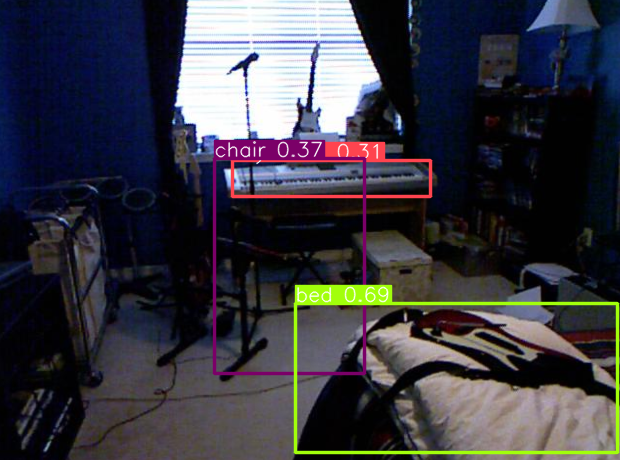

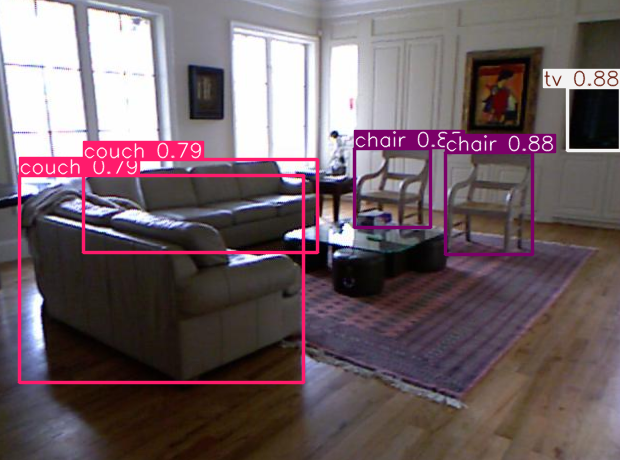

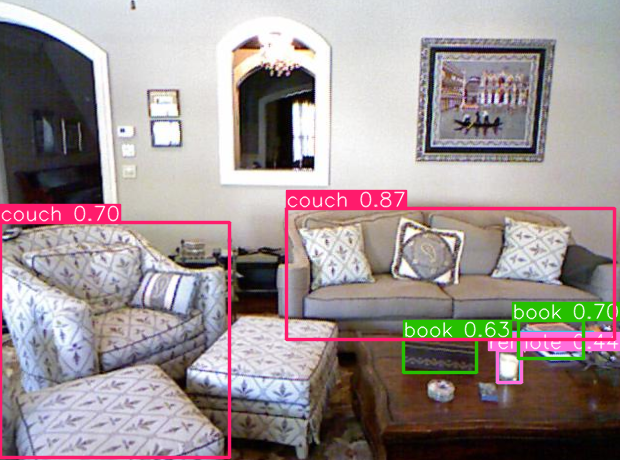

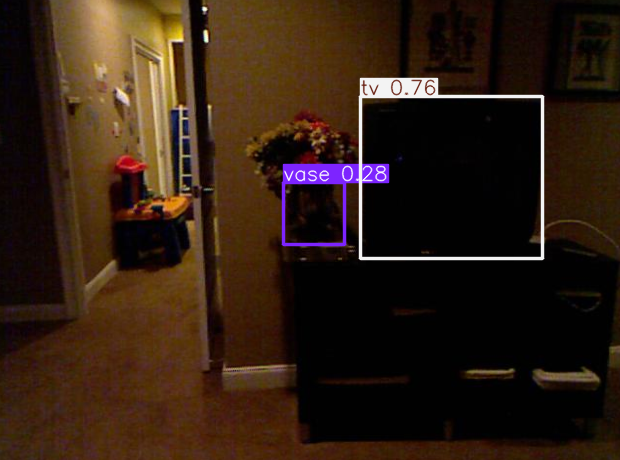

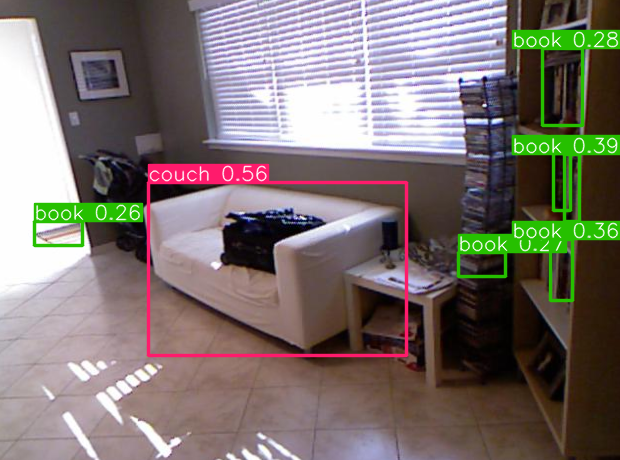

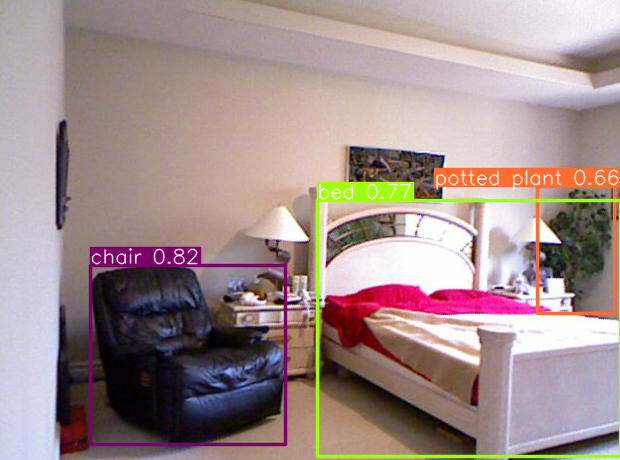

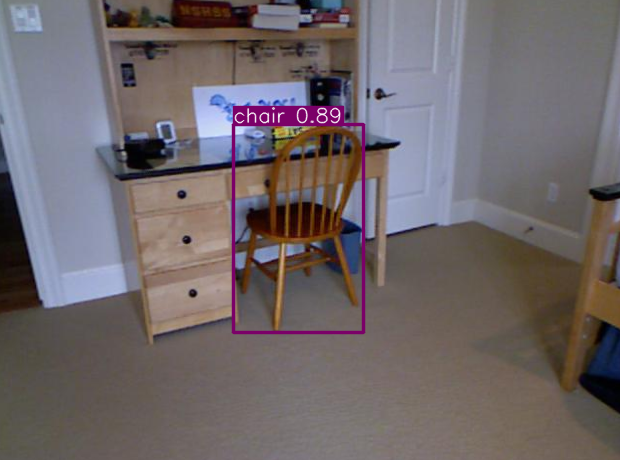

------------------------------------------------------- 



In [3]:
import torch
import os
import random
from IPython.display import Image, display
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Завантажуємо натреновану модель YOLOv5 
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

# 2. Вказуємо шлях до наших тестових зображень
image_dir = 'Indoor Objects Detection/test/images/'

# 3. Отримуємо список усіх файлів-зображень у цій папці
try:
    image_files = os.listdir(image_dir)
    # Відбираємо тільки файли з розширенням .png, .jpg, .jpeg
    image_files = [f for f in image_files if f.endswith(('.png', '.jpg', '.jpeg'))]
except FileNotFoundError:
    print(f"ПОМИЛКА: Папку не знайдено за шляхом: {image_dir}")
    print("Перевірте, чи правильно вказано назву папки 'Indoor Objects Detection'")
    image_files = []


# 4. Вибираємо 3 випадкові картинки для перевірки
if len(image_files) >= 7:
    selected_images = random.sample(image_files, k=7)
    image_paths = [os.path.join(image_dir, img) for img in selected_images]

    # 5. Відправляємо зображення моделі для аналізу
    results = model(image_paths)

    # 6. Візуалізуємо результати: показуємо зображення з рамками (bounding boxes)
    print("\nРезультати виявлення об'єктів:")
    results.show()
    print("-" * 55, "\n")
elif image_files:
    print(f"Знайдено лише {len(image_files)} зображень. Обробляю їх усі.")
    image_paths = [os.path.join(image_dir, img) for img in image_files]
    results = model(image_paths)
    results.show()
else:
    print("У папці test/images не знайдено зображень для обробки.")

#### Завдання 4. Класифікація диких тварин (Snapshot Serengeti) (animal_data)
- Мета: Розпізнавати види тварин у дикій природі.
- Датасет:
    - Snapshot Serengeti (https://lila.science/datasets/snapshot-serengeti)
    - animal_data (https://www.kaggle.com/datasets/likhon148/animal-data)
- Опис:
    - Використати CNN або transfer learning (ResNet, EfficientNet).
    - Навчити класифікувати тварин на кілька популярних класів (лев, слон, зебра).
    - Візуалізувати правильні та неправильні передбачення.
- Очікуваний результат: Модель розпізнає види тварин на фото з точністю ~70–80%.

✅ Все OK.
🔹 Mapping (train) sample: {1: 'cheetah', 5: 'giraffe', 3: 'elephant', 4: 'zebra', 2: 'lion', 0: 'rhino'}
✅ Класи (train): ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Datasets ready: 6107 train, 763 val, 764 test
Num classes: 6
✅ EfficientNetB0 з ImageNet-weights створено.


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape             ┃          Param # ┃ Connected to              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)   │ (None, 224, 224, 3)      │                0 │ -                         │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ data_augmentation             │ (None, 224, 224, 3)      │                0 │ input_layer_13[0][0]      │
│ (Sequential)                  │                          │                  │                           │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ rescaling_10 (Rescaling)      │ (None, 224, 224, 3)      │                0 │ data_augmentation[0][0]   │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ normalization_2               │ (None, 224, 224, 3)      │                7 │ rescaling_10[0][0]        │
│ (Normalization)               │                          │                  │                           │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)      │                0 │ normalization_2[0][0]     │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)     │              864 │ stem_conv_pad[0][0]       │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)     │              128 │ stem_conv[0][0]           │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)     │                0 │ stem_bn[0][0]             │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)     │              288 │ stem_activation[0][0]     │
│ (DepthwiseConv2D)             │                          │                  │                           │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)     │              128 │ block1a_dwconv[0][0]      │
│ (BatchNormalization)          │                          │                  │                           │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)     │                0 │ block1a_bn[0][0]          │
│ (Activation)                  │                          │                  │                           │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)               │                0 │ block1a_activation[0][0]  │
│ (GlobalAveragePooling2D)      │                          │                  │                           │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)         │                0 │ block1a_se_squeeze[0][0]  │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)          │              264 │ block1a_se_reshape[0][0]  │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ bl

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 146s 717ms/step - accuracy: 0.1759 - loss: 1.7912 - val_accuracy: 0.2005 - val_loss: 1.7901
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 113s 567ms/step - accuracy: 0.1800 - loss: 1.7905 - val_accuracy: 0.2005 - val_loss: 1.7894
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 110s 578ms/step - accuracy: 0.1800 - loss: 1.7902 - val_accuracy: 0.2005 - val_loss: 1.7891
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 126s 661ms/step - accuracy: 0.1800 - loss: 1.7900 - val_accuracy: 0.2005 - val_loss: 1.7889
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 124s 566ms/step - accuracy: 0.1800 - loss: 1.7900 - val_accuracy: 0.2005 - val_loss: 1.7889
Epoch 5/13
191/191 ━━━━━━━━━━━━━━━━━━━━ 154s 748ms/step - accuracy: 0.1615 - loss: 1.9163 - val_accuracy: 0.2005 - val_loss: 1.7888
Epoch 6/13
191/191 ━━━━━━━━━━━━━━━━━━━━ 139s 727ms/step - accuracy: 0.1768 - loss: 1.8746 - val_accuracy: 0.2005 - val_loss: 1.7888
Epoch 7/13
191/191 ━━━━━━━━━━━━━━━━━━━━ 141s 738ms/step - accuracy: 0.1746 - loss

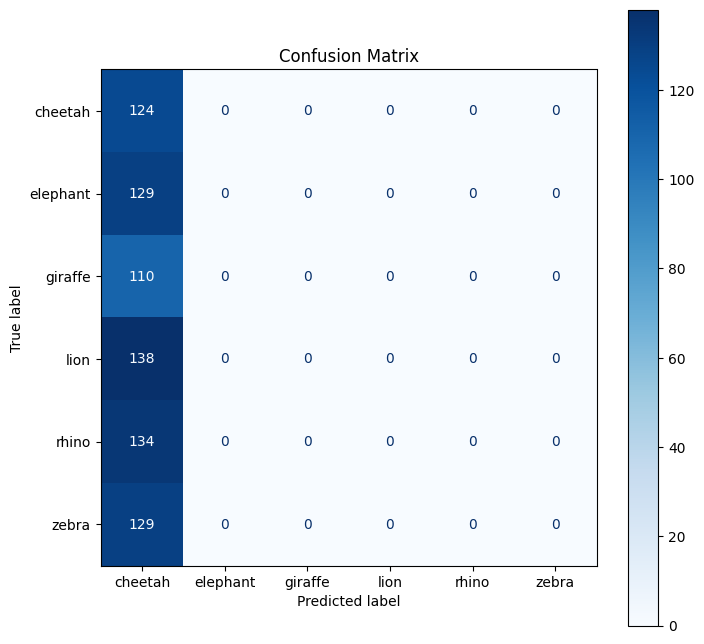


📊 Classification Report:
              precision    recall  f1-score   support

     cheetah     0.1623    1.0000    0.2793       124
    elephant     0.0000    0.0000    0.0000       129
     giraffe     0.0000    0.0000    0.0000       110
        lion     0.0000    0.0000    0.0000       138
       rhino     0.0000    0.0000    0.0000       134
       zebra     0.0000    0.0000    0.0000       129

    accuracy                         0.1623       764
   macro avg     0.0271    0.1667    0.0465       764
weighted avg     0.0263    0.1623    0.0453       764



C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


C:\Users\User\AppData\Local\Temp\ipykernel_32492\484614009.py:248: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


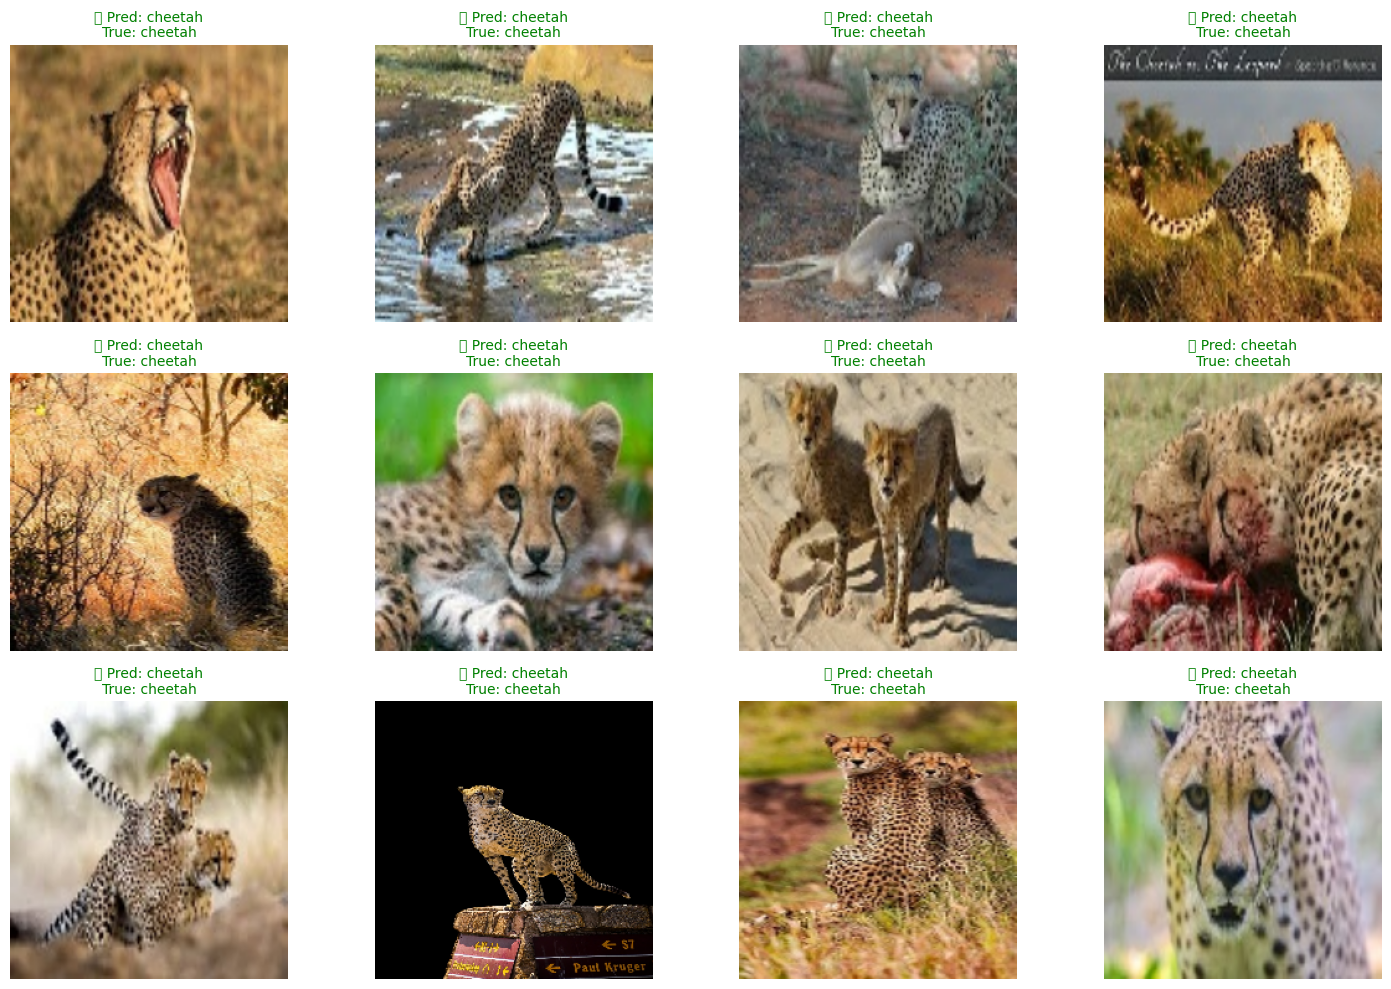

💾 Модель збережена: wild_animals_classifier_final.h5


In [8]:
import os, re, collections, glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from PIL import Image

# ---------- Створимо налаштування ----------
BASE_DIR = "Wild Animals Boundary Box labels"   # <- встанови свій шлях
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
INITIAL_EPOCHS = 5
FINE_TUNE_ADDITIONAL_EPOCHS = 8
SEED = 42

# ---------- Перевіремо шлях папок ----------
images_dir = os.path.join(BASE_DIR, "images")
labels_dir = os.path.join(BASE_DIR, "labels")
train_img_dir = os.path.join(images_dir, "train")
val_img_dir   = os.path.join(images_dir, "valid")
test_img_dir  = os.path.join(images_dir, "test")
train_lbl_dir = os.path.join(labels_dir, "train")
val_lbl_dir   = os.path.join(labels_dir, "valid")
test_lbl_dir  = os.path.join(labels_dir, "test")

for p in [train_img_dir, val_img_dir, test_img_dir]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Не знайдено шлях: {p}")
print("✅ Все OK.")

# ---------- Створимо допоміжні утиліти для імен ----------------
def get_stem(fname):
    return os.path.splitext(os.path.basename(fname))[0]

def extract_name_from_filename(fname):
    """Витягує назву виду з імені файлу, напр.: cheetah1299.jpg -> cheetah"""
    base = os.path.basename(fname)
    m = re.match(r'^([A-Za-z]+)', base)
    if m:
        return m.group(1).lower()
    base_noext = os.path.splitext(base)[0]
    return base_noext.split("_")[0].lower()

def read_label_index_for_image(img_path, labels_folder):
    """Зчитує індекс класу з відповідного .txt (якщо є)."""
    stem = get_stem(img_path)
    txt_path = os.path.join(labels_folder, stem + ".txt")
    if not os.path.exists(txt_path):
        return None
    try:
        with open(txt_path, "r", encoding="utf-8") as f:
            line = f.readline().strip()
            if not line:
                return None
            parts = line.split()
            return int(float(parts[0]))
    except Exception:
        return None

# ---------- Побудуємо mapping numeric_class -> textual_name ----------
def build_classname_mapping(img_folder, lbl_folder):
    """
    Для кожного числового індексу (якщо він є у .txt) знаходимо найчастішу текстову назву,
    витягнену з імені файлу. Це дозволяє зіставити '1' -> 'cheetah' тощо.
    """
    counter_map = collections.defaultdict(collections.Counter)
    files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for f in files:
        img_path = os.path.join(img_folder, f)
        cls_idx = read_label_index_for_image(img_path, lbl_folder)
        name = extract_name_from_filename(f)
        if cls_idx is None:
            counter_map[-1][name] += 1
        else:
            counter_map[cls_idx][name] += 1
    final = {k: cnt.most_common(1)[0][0] for k, cnt in counter_map.items()}
    return final

train_map = build_classname_mapping(train_img_dir, train_lbl_dir)
print("🔹 Mapping (train) sample:", train_map)

def build_entries(img_folder, lbl_folder, numeric_to_name_map):
    """Повертає список (path, class_name) для кожного зображення в папці."""
    entries = []
    for f in os.listdir(img_folder):
        if not f.lower().endswith(('.jpg','.jpeg','.png')):
            continue
        p = os.path.join(img_folder, f)
        cls_idx = read_label_index_for_image(p, lbl_folder)
        cls_name = numeric_to_name_map.get(cls_idx, extract_name_from_filename(f))
        entries.append((p, cls_name))
    return entries

train_entries = build_entries(train_img_dir, train_lbl_dir, train_map)
val_entries   = build_entries(val_img_dir, val_lbl_dir, train_map)
test_entries  = build_entries(test_img_dir, test_lbl_dir, train_map)

# Побудуємо фінальний список класів (тільки ті, що зустрічаються у train)
all_class_names = sorted(list({c for _, c in train_entries}))
name_to_idx = {n: i for i, n in enumerate(all_class_names)}
NUM_CLASSES = len(all_class_names)
print("✅ Класи (train):", all_class_names)

# Видалимо записи вал/тест, які не належать до класів train (щоб уникнути невідповідностей)
def filter_allowed(entries, allowed_set):
    filtered = [(p,c) for p,c in entries if c in allowed_set]
    dropped = len(entries) - len(filtered)
    if dropped:
        print(f"⚠️ Dropped {dropped} entries not in train-classes.")
    return filtered

val_entries = filter_allowed(val_entries, set(all_class_names))
test_entries = filter_allowed(test_entries, set(all_class_names))

# ---------- tf.data pipeline ----------
def paths_labels_to_dataset(entries, batch_size, shuffle=False):
    paths = [p for p,_ in entries]
    labels = [name_to_idx[c] for _,c in entries]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
        
    def _load(path, label):
        image = tf.io.read_file(path)
        image = tf.io.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = tf.cast(image, tf.float32) / 255.0
        label = tf.cast(label, tf.int32)  # ✅ важливо для Keras 3
        return image, label
    
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = paths_labels_to_dataset(train_entries, BATCH_SIZE, shuffle=True)
val_ds   = paths_labels_to_dataset(val_entries, BATCH_SIZE)
test_ds  = paths_labels_to_dataset(test_entries, BATCH_SIZE)

print("Datasets ready:", len(train_entries), "train,", len(val_entries), "val,", len(test_entries), "test")
print("Num classes:", NUM_CLASSES)

# Проведемо легку аугментацію для тренування (використовується в pipeline)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08)
], name="data_augmentation")


# ---------- Побудуємо модель (EfficientNetB0) ----------
def build_model(num_classes):
    """
    Побудова моделі з коректним обробленням use_pretrained.
    Передаємо input_tensor, щоб уникнути mismatch форм.
    Повертає tuple (model, base_model).
    """
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)  # аугментація всередині моделі
    base_model = EfficientNetB0(include_top=False, weights=None, input_tensor=x, pooling="avg")
    base_model.trainable = False
    x = layers.Dropout(0.3)(base_model.output)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    return model, base_model


# ---------- Ініціалізуємо моделі з безпечним fallback ----------
try:
    model, base_model = build_model(NUM_CLASSES)
    print("✅ EfficientNetB0 з ImageNet-weights створено.")
except Exception as e:
    print("⚠️ Не вдалося завантажити ImageNet-weights або інша помилка:", e)
    print("   Перехід на weights=None (навчимо з нуля або з часткового переносу).")
    model, base_model = build_model(NUM_CLASSES, use_pretrained=False)

# Компіляція
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

# ---------- Розпочнемо навчання (feature-extraction) ----------
history = model.fit(train_ds, validation_data=val_ds, epochs=INITIAL_EPOCHS)

# ---------- Fine-tuning (розморозимо кінцеві шари бази) ----------
base_model.trainable = True
for layer in base_model.layers[:-20]:  # залишаємо тренуваними тільки останні 20 шарів
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_fine = model.fit(train_ds, validation_data=val_ds,
                         epochs=INITIAL_EPOCHS + FINE_TUNE_ADDITIONAL_EPOCHS,
                         initial_epoch=history.epoch[-1])

# ---------- Проведемо оцінку на тесті ----------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n🎯 Точність на тестових зображеннях: {test_acc*100:.2f}%")

# ---------- Confusion Matrix та Classification Report ----------
print("\n🔹 Обчислюємо передбачення на тесті...")
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_class_names)
disp.plot(cmap="Blues", values_format='d', ax=plt.gca())
plt.title("Confusion Matrix")
plt.show()

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=all_class_names, digits=4))

# ---------- Візуалізуємо приклади (12) з маркуванням правильності ----------
def show_examples_from_test(ds, n=12, seed=RANDOM_STATE):
    # візьмемо перші батчі та виберемо n випадкових індексів
    np.random.seed(seed)
    images_list = []
    labels_list = []
    paths_list = []  # у випадку, якщо потрібно шляхи (не доступні тут)
    for images, labels in ds.take(1):
        images_list = images.numpy()
        labels_list = labels.numpy()
    n_show = min(n, images_list.shape[0])
    idxs = np.random.choice(images_list.shape[0], n_show, replace=False)
    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(idxs):
        img = (images_list[idx] * 255).astype("uint8")
        true_label = all_class_names[labels_list[idx]]
        pred = model.predict(images_list[idx:idx+1])
        pred_label = all_class_names[int(np.argmax(pred, axis=1)[0])]
        correct = (true_label == pred_label)
        ax = plt.subplot(int(np.ceil(n_show/4)), 4, i+1)
        plt.imshow(img)
        title = f"{'✅' if correct else '❌'} Pred: {pred_label}\nTrue: {true_label}"
        plt.title(title, color="green" if correct else "red", fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_examples_from_test(test_ds, n=12)

# ---------- Збережмо моделі ----------
out_name = "wild_animals_classifier_final.h5"
model.save(out_name)
print(f"💾 Модель збережена: {out_name}")
